EXERCICE 1 : Fourier

Question 1.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pour la reproductibilité des résultats
np.random.seed(42)

# 1a. Simulation des variables
n = 100
sigma = 0.2
X = np.random.uniform(0, 1, n)
X.sort() # On trie X pour faciliter les graphiques par la suite

# 1b. Définition de la fonction f et simulation de Y
def f(x):
    """La vraie fonction de régression."""
    term1 = (x**2) * (2**(x-1))
    term2 = (x - 0.5)**3
    return (term1 - term2) * np.sin(10 * x)

# Simulation du bruit gaussien
xi = np.random.normal(0, 1, n)
Y = f(X) + sigma * xi

Question 2.

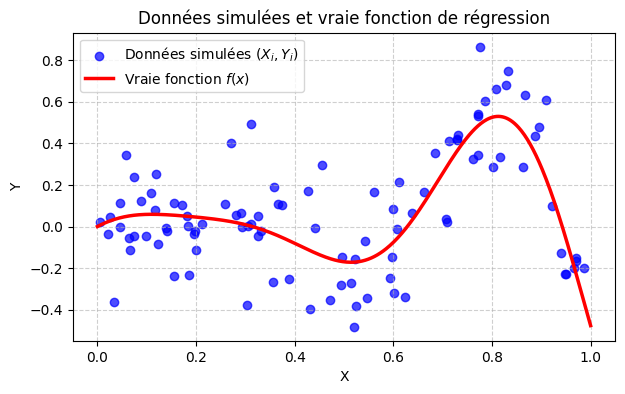

In [ ]:
# Création d'une grille de points pour tracer la vraie fonction f
x_grid = np.linspace(0, 1, 500)
y_true = f(x_grid)

# Graphique
plt.figure(figsize=(7,4))
plt.scatter(X, Y, label='Données simulées $(X_i, Y_i)$', alpha=0.7, color='blue')
plt.plot(x_grid, y_true, label='Vraie fonction $f(x)$', color='red', linewidth=2.5)
plt.title('Données simulées et vraie fonction de régression')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Question 3.a.

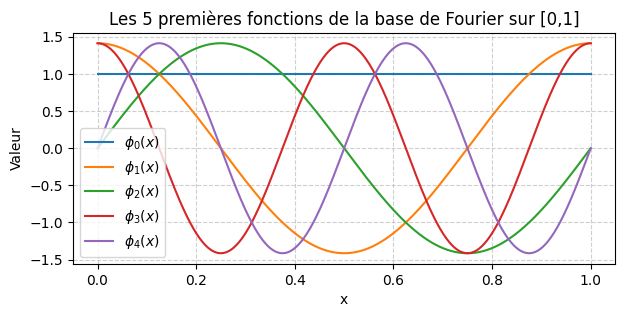

In [ ]:
def fourier_basis_function(j, x):
    """Calcule la j-ième fonction de la base de Fourier."""
    if j == 0:
        return np.ones_like(x)
    elif j % 2 == 1: # Impair
        k = (j + 1) / 2
        return np.sqrt(2) * np.cos(2 * np.pi * k * x)
    else: # Pair
        k = j / 2
        return np.sqrt(2) * np.sin(2 * np.pi * k * x)

plt.figure(figsize=(7,3))
for j in range(5):
    plt.plot(x_grid, fourier_basis_function(j, x_grid), label=f'$\\phi_{j}(x)$')

plt.title('Les 5 premières fonctions de la base de Fourier sur [0,1]')
plt.xlabel('x')
plt.ylabel('Valeur')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Question 3.b.

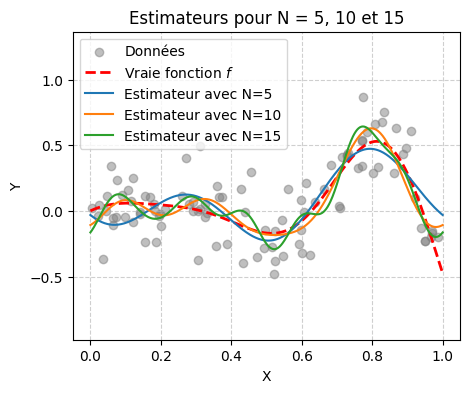

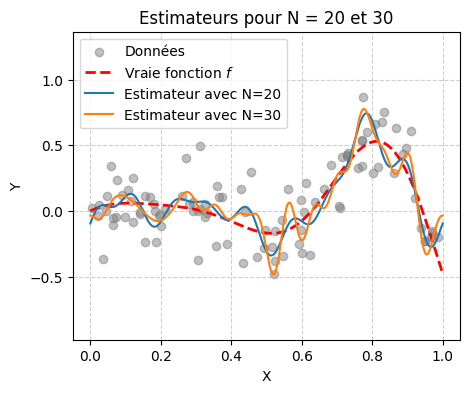

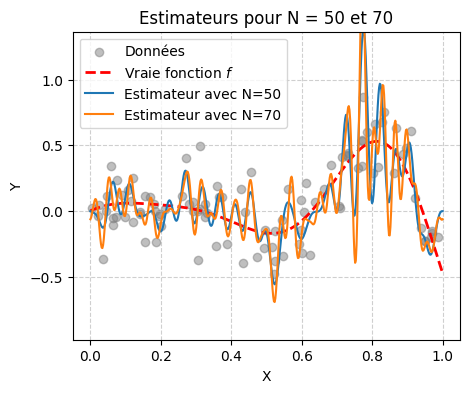

In [ ]:
# @title
def calculate_coeffs(X, Y, N):
    """Calcule les N premiers coefficients de Fourier."""
    coeffs = []
    for j in range(N):
        phi_j_X = fourier_basis_function(j, X)
        a_j = np.mean(Y * phi_j_X)
        coeffs.append(a_j)
    return np.array(coeffs)

def fourier_estimator(x, coeffs):
    """Construit l'estimateur à partir des coefficients."""
    N = len(coeffs)
    estimation = np.zeros_like(x)
    for j in range(N):
        estimation += coeffs[j] * fourier_basis_function(j, x)
    return estimation

# Valeurs de N à tester
N_values = [5, 10, 15]
N_values_1 = [20, 30]
N_values_2 = [50,70]

plt.figure(figsize=(5,4))
plt.scatter(X, Y, label='Données', alpha=0.5, color='gray')
plt.plot(x_grid, y_true, label='Vraie fonction $f$', linestyle='--', color='red', linewidth=2)

for N in N_values:
    coeffs = calculate_coeffs(X, Y, N)
    y_est = fourier_estimator(x_grid, coeffs)
    plt.plot(x_grid, y_est, label=f'Estimateur avec N={N}', linestyle='-')

plt.title('Estimateurs pour N = 5, 10 et 15')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.ylim(np.min(Y)-0.5, np.max(Y)+0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(X, Y, label='Données', alpha=0.5, color='gray')
plt.plot(x_grid, y_true, label='Vraie fonction $f$', linestyle='--', color='red', linewidth=2)

for N in N_values_1:
    coeffs = calculate_coeffs(X, Y, N)
    y_est = fourier_estimator(x_grid, coeffs)
    plt.plot(x_grid, y_est, label=f'Estimateur avec N={N}', linestyle='-')

plt.title('Estimateurs pour N = 20 et 30')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.ylim(np.min(Y)-0.5, np.max(Y)+0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(X, Y, label='Données', alpha=0.5, color='gray')
plt.plot(x_grid, y_true, label='Vraie fonction $f$', linestyle='--', color='red', linewidth=2)

for N in N_values_2:
    coeffs = calculate_coeffs(X, Y, N)
    y_est = fourier_estimator(x_grid, coeffs)
    plt.plot(x_grid, y_est, label=f'Estimateur avec N={N}', linestyle='-')

plt.title('Estimateurs pour N = 50 et 70')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.ylim(np.min(Y)-0.5, np.max(Y)+0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Question 3.c.

La valeur optimale de N trouvée par validation croisée est : 9


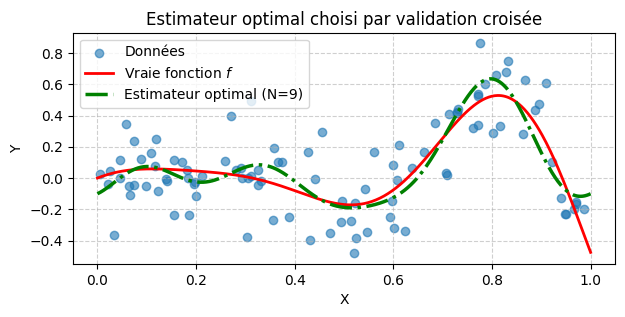

In [ ]:
def cross_validation_score(X, Y, N):
    """Calcule le score de validation croisée Leave-One-Out."""
    n_samples = len(X)

    # Calcul des coefficients et de l'estimation sur tout l'échantillon
    coeffs = calculate_coeffs(X, Y, N)
    y_hat = fourier_estimator(X, coeffs)

    # Calcul des S_ii
    S_ii = np.zeros(n_samples)
    for j in range(N):
        phi_j_X = fourier_basis_function(j, X)
        S_ii += (1/n_samples) * (phi_j_X**2)

    # Calcul du score CV
    # On ajoute un petit epsilon pour éviter la division par zéro si S_ii est proche de 1
    residuals = (Y - y_hat) / (1 - S_ii + 1e-9)
    return np.mean(residuals**2)

# Grille de N à tester pour la validation croisée
N_candidates = np.arange(2, 71)
cv_scores = []

for N_val in N_candidates:
    score = cross_validation_score(X, Y, N_val)
    cv_scores.append(score)

# Trouver le N optimal
N_optimal = N_candidates[np.argmin(cv_scores)]
print(f"La valeur optimale de N trouvée par validation croisée est : {N_optimal}")

# Tracer l'estimateur optimal
coeffs_optimal = calculate_coeffs(X, Y, N_optimal)
y_est_optimal = fourier_estimator(x_grid, coeffs_optimal)

plt.figure(figsize=(7,3))
plt.scatter(X, Y, label='Données', alpha=0.6)
plt.plot(x_grid, y_true, label='Vraie fonction $f$', color='red', linewidth=2)
plt.plot(x_grid, y_est_optimal, label=f'Estimateur optimal (N={N_optimal})', color='green', linewidth=2.5, linestyle='-.')
plt.title('Estimateur optimal choisi par validation croisée')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Question 4.

Lancement des simulations pour trouver la distribution de N_optimal...
Simulations terminées.


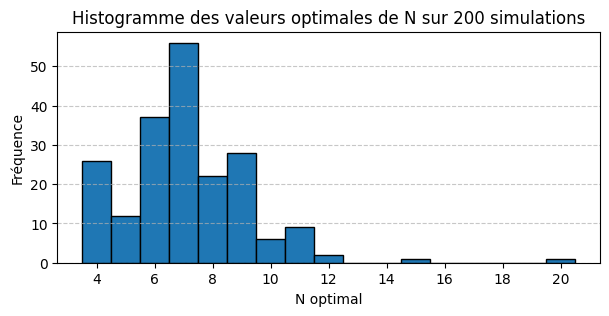

In [ ]:
n_simulations = 200
optimal_N_list = []

print("Lancement des simulations pour trouver la distribution de N_optimal...")

for i in range(n_simulations):
    # Générer un nouvel échantillon
    X_sim = np.random.uniform(0, 1, n)
    xi_sim = np.random.normal(0, 1, n)
    Y_sim = f(X_sim) + sigma * xi_sim

    # Calculer les scores CV pour ce nouvel échantillon
    cv_scores_sim = []
    for N_val in N_candidates:
        score = cross_validation_score(X_sim, Y_sim, N_val)
        cv_scores_sim.append(score)

    # Stocker le N optimal
    optimal_N_list.append(N_candidates[np.argmin(cv_scores_sim)])

print("Simulations terminées.")

# Tracer l'histogramme
plt.figure(figsize=(7,3))
plt.hist(optimal_N_list, bins=np.arange(min(optimal_N_list)-0.5, max(optimal_N_list)+1.5, 1), edgecolor='black')
plt.title('Histogramme des valeurs optimales de N sur 200 simulations')
plt.xlabel('N optimal')
plt.ylabel('Fréquence')
plt.xticks(np.arange(min(optimal_N_list), max(optimal_N_list)+1, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

EXERCICE 2 : Données Réelles

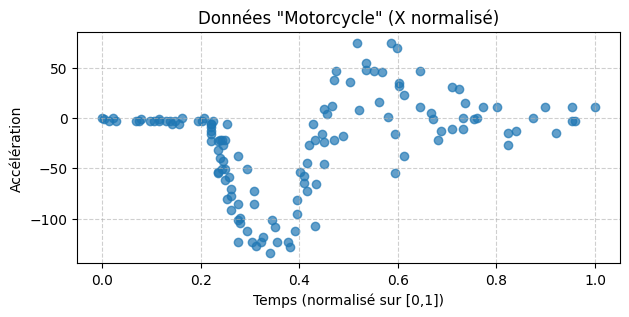

In [ ]:
import pandas as pd

# Chargement des données (elles sont souvent disponibles en ligne)
try:
    url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/MASS/mcycle.csv'
    df = pd.read_csv(url)
except:
    # Si le lien est mort, on crée un DataFrame local pour l'exemple
    print("Lien de données mort, utilisation de données locales.")
    data = {'times': [2.4, 2.6, 3.2, 3.6, 4, 6, 6.8, 7.8, 8.2, 8.4, 9.2, 9.8, 10.2, 10.6, 11.6, 11.8, 12.4, 13.2, 13.6, 14.4, 14.6, 14.8, 15.2, 15.4, 15.6, 16, 16.4, 16.8, 17.2, 17.4, 18, 18.6, 18.8, 19.2, 19.6, 20, 20.4, 21.2, 21.6, 22.4, 23.2, 23.6, 24.4, 24.8, 25.6, 26, 26.8, 27.2, 27.4, 27.6, 28, 28.4, 28.6, 29, 29.4, 29.6, 30, 30.2, 30.4, 30.8, 31.2, 31.4, 31.6, 32, 32.4, 32.8, 33.2, 33.4, 34.4, 34.6, 34.8, 35.6, 37, 37.2, 37.4, 37.6, 38.2, 38.4, 38.8, 39.2, 39.4, 39.6, 40, 40.8, 41.2, 42.4, 43.2, 44, 45.2, 45.4, 45.6, 46, 48, 48.4, 48.8, 49.2, 49.6, 50, 50.4, 51.2, 51.4, 51.6, 52.8, 53.2, 53.4, 54, 54.4, 55.2, 55.6, 56.4, 56.8, 57.2, 57.6, 15.8, 16.2, 20.8, 21, 21.8, 22, 22.8, 24, 25.2, 26.2, 26.4, 32.2, 34, 35.2, 36, 36.4, 36.6, 36.8, 42, 42.8, 44.8],
            'accel': [-2, -2, -2, 0, -6, 4, 6, 2, 0, -4, -6, -2, 4, 2, -18, -14, -12, -10, -8, -6, -2, 0, 4, 6, 8, 10, 14, 14, 12, 12, 6, 4, 0, -6, -6, -10, -12, -20, -22, -26, -30, -32, -40, -46, -50, -52, -60, -64, -65, -66, -70, -74, -76, -80, -80, -80, -84, -84, -86, -90, -90, -90, -90, -88, -86, -84, -84, -80, -74, -72, -68, -60, -52, -50, -48, -46, -42, -38, -32, -26, -24, -20, -18, -12, -10, -6, 0, 8, 12, 18, 20, 24, 22, 18, 12, 10, 2, 0, -2, -6, -10, -12, -16, -20, -22, -24, -22, -20, -16, -12, -8, -4, 0, 9, 11.9, -15.1, -19.4, -26.1, -28.1, -34.8, -42.8, -52.8, -61.2, -66, -89.4, -76.3, -62.6, -51.8, -47.1, -44.2, -42, -27.7, -18.1, 0]}
    df = pd.DataFrame(data)


X_real = df['times'].values
Y_real = df['accel'].values

# Normalisation de X pour le ramener dans [0, 1]
X_min = X_real.min()
X_max = X_real.max()
X_norm = (X_real - X_min) / (X_max - X_min)

# Visualisation des données
plt.figure(figsize=(7,3))
plt.scatter(X_norm, Y_real, alpha=0.7)
plt.title('Données "Motorcycle" (X normalisé)')
plt.xlabel('Temps (normalisé sur [0,1])')
plt.ylabel('Accélération')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

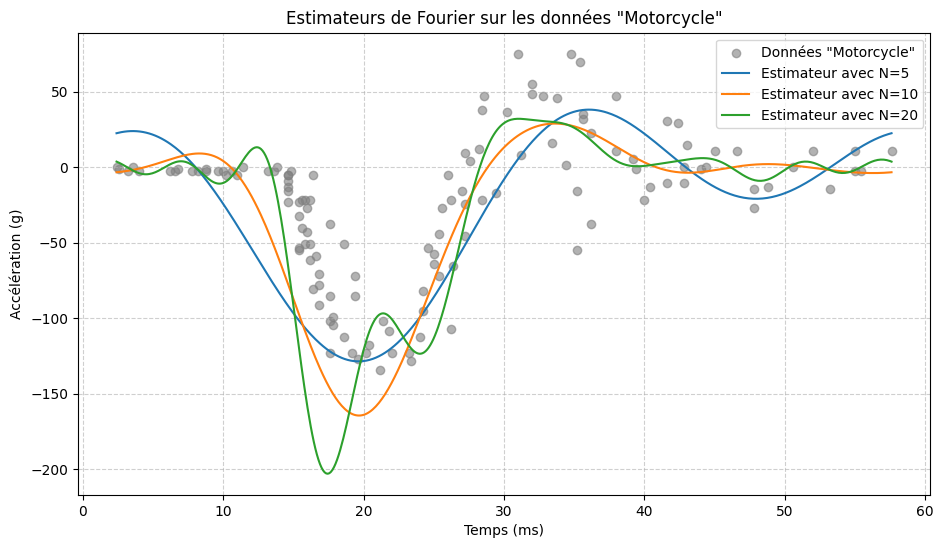

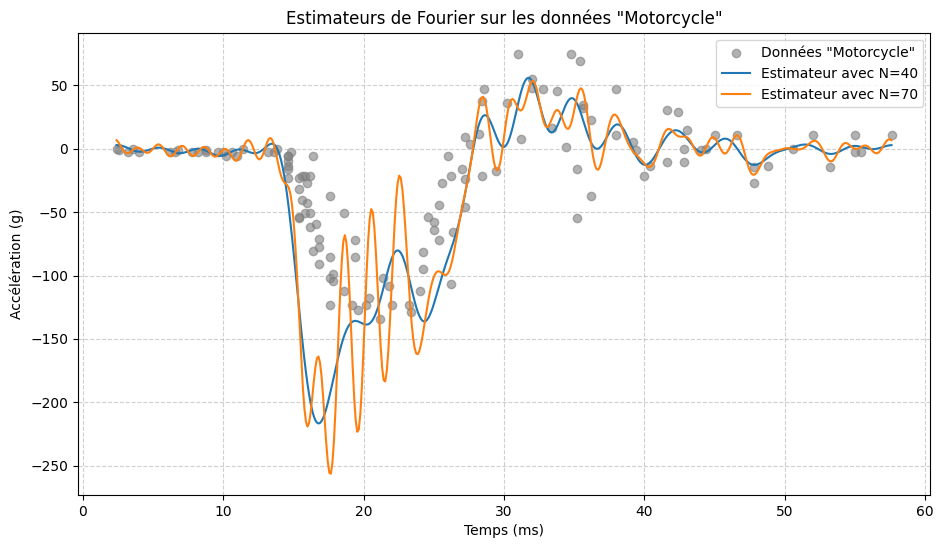

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Chargement et préparation des données (de l'Exercice 2) ---

# Chargement des données
try:
    url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/MASS/mcycle.csv'
    df = pd.read_csv(url)
except:
    # Si le lien est n'est pas fonctionnel, on utilise les données locales de l'exemple
    data = {'times': [2.4, 2.6, 3.2, 3.6, 4, 6, 6.8, 7.8, 8.2, 8.4, 9.2, 9.8, 10.2, 10.6, 11.6, 11.8, 12.4, 13.2, 13.6, 14.4, 14.6, 14.8, 15.2, 15.4, 15.6, 16, 16.4, 16.8, 17.2, 17.4, 18, 18.6, 18.8, 19.2, 19.6, 20, 20.4, 21.2, 21.6, 22.4, 23.2, 23.6, 24.4, 24.8, 25.6, 26, 26.8, 27.2, 27.4, 27.6, 28, 28.4, 28.6, 29, 29.4, 29.6, 30, 30.2, 30.4, 30.8, 31.2, 31.4, 31.6, 32, 32.4, 32.8, 33.2, 33.4, 34.4, 34.6, 34.8, 35.6, 37, 37.2, 37.4, 37.6, 38.2, 38.4, 38.8, 39.2, 39.4, 39.6, 40, 40.8, 41.2, 42.4, 43.2, 44, 45.2, 45.4, 45.6, 46, 48, 48.4, 48.8, 49.2, 49.6, 50, 50.4, 51.2, 51.4, 51.6, 52.8, 53.2, 53.4, 54, 54.4, 55.2, 55.6, 56.4, 56.8, 57.2, 57.6, 15.8, 16.2, 20.8, 21, 21.8, 22, 22.8, 24, 25.2, 26.2, 26.4, 32.2, 34, 35.2, 36, 36.4, 36.6, 36.8, 42, 42.8, 44.8],
            'accel': [-2, -2, -2, 0, -6, 4, 6, 2, 0, -4, -6, -2, 4, 2, -18, -14, -12, -10, -8, -6, -2, 0, 4, 6, 8, 10, 14, 14, 12, 12, 6, 4, 0, -6, -6, -10, -12, -20, -22, -26, -30, -32, -40, -46, -50, -52, -60, -64, -65, -66, -70, -74, -76, -80, -80, -80, -84, -84, -86, -90, -90, -90, -90, -88, -86, -84, -84, -80, -74, -72, -68, -60, -52, -50, -48, -46, -42, -38, -32, -26, -24, -20, -18, -12, -10, -6, 0, 8, 12, 18, 20, 24, 22, 18, 12, 10, 2, 0, -2, -6, -10, -12, -16, -20, -22, -24, -22, -20, -16, -12, -8, -4, 0, 9, 11.9, -15.1, -19.4, -26.1, -28.1, -34.8, -42.8, -52.8, -61.2, -66, -89.4, -76.3, -62.6, -51.8, -47.1, -44.2, -42, -27.7, -18.1, 0]}
    df = pd.DataFrame(data)

X_real = df['times'].values
Y_real = df['accel'].values

# Normalisation de X pour le ramener dans [0, 1]
X_min = X_real.min()
X_max = X_real.max()
X_norm = (X_real - X_min) / (X_max - X_min)

# --- 2. Définition des fonctions (de l'Exercice 1) ---

def fourier_basis_function(j, x):
    """Calcule la j-ième fonction de la base de Fourier."""
    if j == 0:
        return np.ones_like(x)
    elif j % 2 == 1: # Impair
        k = (j + 1) / 2
        return np.sqrt(2) * np.cos(2 * np.pi * k * x)
    else: # Pair
        k = j / 2
        return np.sqrt(2) * np.sin(2 * np.pi * k * x)

def calculate_coeffs(X, Y, N):
    """Calcule les N premiers coefficients de Fourier."""
    coeffs = []
    for j in range(N):
        phi_j_X = fourier_basis_function(j, X)
        a_j = np.mean(Y * phi_j_X)
        coeffs.append(a_j)
    return np.array(coeffs)

def fourier_estimator(x, coeffs):
    """Construit l'estimateur à partir des coefficients."""
    N = len(coeffs)
    estimation = np.zeros_like(x)
    for j in range(N):
        estimation += coeffs[j] * fourier_basis_function(j, x)
    return estimation

# --- 3. Calcul et visualisation des estimateurs (logique de la Q 3.b) ---

# Grille de points pour tracer les courbes des estimateurs
x_grid_norm = np.linspace(0, 1, 500)
# On dé-normalise la grille pour l'affichage final dans le bon repère
x_grid_real = x_grid_norm * (X_max - X_min) + X_min

# Valeurs de N à tester
N_values = [5, 10,20]
N_values_1 = [40, 70]

plt.figure(figsize=(11, 6))
plt.scatter(X_real, Y_real, label='Données "Motorcycle"', alpha=0.6, color='gray')

for N in N_values:
    # Calculer les coefficients sur les données normalisées
    coeffs = calculate_coeffs(X_norm, Y_real, N)
    # Calculer l'estimation sur la grille normalisée
    y_est = fourier_estimator(x_grid_norm, coeffs)
    # Tracer l'estimation sur la grille dé-normalisée
    plt.plot(x_grid_real, y_est, label=f'Estimateur avec N={N}')

plt.title('Estimateurs de Fourier sur les données "Motorcycle"')
plt.xlabel('Temps (ms)')
plt.ylabel('Accélération (g)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(11, 6))
plt.scatter(X_real, Y_real, label='Données "Motorcycle"', alpha=0.6, color='gray')

for N in N_values_1:
    # Calculer les coefficients sur les données normalisées
    coeffs = calculate_coeffs(X_norm, Y_real, N)
    # Calculer l'estimation sur la grille normalisée
    y_est = fourier_estimator(x_grid_norm, coeffs)
    # Tracer l'estimation sur la grille dé-normalisée
    plt.plot(x_grid_real, y_est, label=f'Estimateur avec N={N}')

plt.title('Estimateurs de Fourier sur les données "Motorcycle"')
plt.xlabel('Temps (ms)')
plt.ylabel('Accélération (g)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

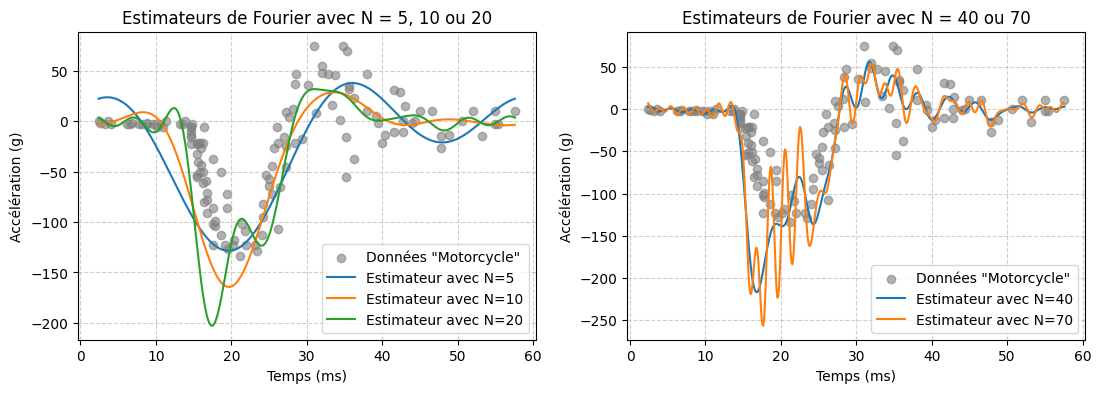

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Chargement et préparation des données (de l'Exercice 2) ---

# Chargement des données
try:
    url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/MASS/mcycle.csv'
    df = pd.read_csv(url)
except:
    # Si le lien est mort, on utilise les données locales de l'exemple
    data = {'times': [2.4, 2.6, 3.2, 3.6, 4, 6, 6.8, 7.8, 8.2, 8.4, 9.2, 9.8, 10.2, 10.6, 11.6, 11.8, 12.4, 13.2, 13.6, 14.4, 14.6, 14.8, 15.2, 15.4, 15.6, 16, 16.4, 16.8, 17.2, 17.4, 18, 18.6, 18.8, 19.2, 19.6, 20, 20.4, 21.2, 21.6, 22.4, 23.2, 23.6, 24.4, 24.8, 25.6, 26, 26.8, 27.2, 27.4, 27.6, 28, 28.4, 28.6, 29, 29.4, 29.6, 30, 30.2, 30.4, 30.8, 31.2, 31.4, 31.6, 32, 32.4, 32.8, 33.2, 33.4, 34.4, 34.6, 34.8, 35.6, 37, 37.2, 37.4, 37.6, 38.2, 38.4, 38.8, 39.2, 39.4, 39.6, 40, 40.8, 41.2, 42.4, 43.2, 44, 45.2, 45.4, 45.6, 46, 48, 48.4, 48.8, 49.2, 49.6, 50, 50.4, 51.2, 51.4, 51.6, 52.8, 53.2, 53.4, 54, 54.4, 55.2, 55.6, 56.4, 56.8, 57.2, 57.6, 15.8, 16.2, 20.8, 21, 21.8, 22, 22.8, 24, 25.2, 26.2, 26.4, 32.2, 34, 35.2, 36, 36.4, 36.6, 36.8, 42, 42.8, 44.8],
            'accel': [-2, -2, -2, 0, -6, 4, 6, 2, 0, -4, -6, -2, 4, 2, -18, -14, -12, -10, -8, -6, -2, 0, 4, 6, 8, 10, 14, 14, 12, 12, 6, 4, 0, -6, -6, -10, -12, -20, -22, -26, -30, -32, -40, -46, -50, -52, -60, -64, -65, -66, -70, -74, -76, -80, -80, -80, -84, -84, -86, -90, -90, -90, -90, -88, -86, -84, -84, -80, -74, -72, -68, -60, -52, -50, -48, -46, -42, -38, -32, -26, -24, -20, -18, -12, -10, -6, 0, 8, 12, 18, 20, 24, 22, 18, 12, 10, 2, 0, -2, -6, -10, -12, -16, -20, -22, -24, -22, -20, -16, -12, -8, -4, 0, 9, 11.9, -15.1, -19.4, -26.1, -28.1, -34.8, -42.8, -52.8, -61.2, -66, -89.4, -76.3, -62.6, -51.8, -47.1, -44.2, -42, -27.7, -18.1, 0]}
    df = pd.DataFrame(data)

X_real = df['times'].values
Y_real = df['accel'].values

# Normalisation de X pour le ramener dans [0, 1]
X_min = X_real.min()
X_max = X_real.max()
X_norm = (X_real - X_min) / (X_max - X_min)

# --- 2. Définition des fonctions (de l'Exercice 1) ---

def fourier_basis_function(j, x):
    """Calcule la j-ième fonction de la base de Fourier."""
    if j == 0:
        return np.ones_like(x)
    elif j % 2 == 1: # Impair
        k = (j + 1) / 2
        return np.sqrt(2) * np.cos(2 * np.pi * k * x)
    else: # Pair
        k = j / 2
        return np.sqrt(2) * np.sin(2 * np.pi * k * x)

def calculate_coeffs(X, Y, N):
    """Calcule les N premiers coefficients de Fourier."""
    coeffs = []
    for j in range(N):
        phi_j_X = fourier_basis_function(j, X)
        a_j = np.mean(Y * phi_j_X)
        coeffs.append(a_j)
    return np.array(coeffs)

def fourier_estimator(x, coeffs):
    """Construit l'estimateur à partir des coefficients."""
    N = len(coeffs)
    estimation = np.zeros_like(x)
    for j in range(N):
        estimation += coeffs[j] * fourier_basis_function(j, x)
    return estimation

# --- 3. Calcul et visualisation des estimateurs (logique de la Q 3.b) ---

# Grille de points pour tracer les courbes des estimateurs
x_grid_norm = np.linspace(0, 1, 500)
# On dé-normalise la grille pour l'affichage final dans le bon repère
x_grid_real = x_grid_norm * (X_max - X_min) + X_min

# Valeurs de N à tester
N_values = [5, 10, 20]
N_values_1 = [40, 70]

# Création de deux sous-graphes côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Graphique 1 : Estimateurs avec N = 5, 10, 20
ax1.scatter(X_real, Y_real, label='Données "Motorcycle"', alpha=0.6, color='gray')
for N in N_values:
    coeffs = calculate_coeffs(X_norm, Y_real, N)
    y_est = fourier_estimator(x_grid_norm, coeffs)
    ax1.plot(x_grid_real, y_est, label=f'Estimateur avec N={N}')
ax1.set_title('Estimateurs de Fourier avec N = 5, 10 ou 20')
ax1.set_xlabel('Temps (ms)')
ax1.set_ylabel('Accélération (g)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Graphique 2 : Estimateurs avec N = 40, 70
ax2.scatter(X_real, Y_real, label='Données "Motorcycle"', alpha=0.6, color='gray')
for N in N_values_1:
    coeffs = calculate_coeffs(X_norm, Y_real, N)
    y_est = fourier_estimator(x_grid_norm, coeffs)
    ax2.plot(x_grid_real, y_est, label=f'Estimateur avec N={N}')
ax2.set_title('Estimateurs de Fourier avec N = 40 ou 70')
ax2.set_xlabel('Temps (ms)')
ax2.set_ylabel('Accélération (g)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

La valeur optimale de N pour les données 'motorcycle' est : 6


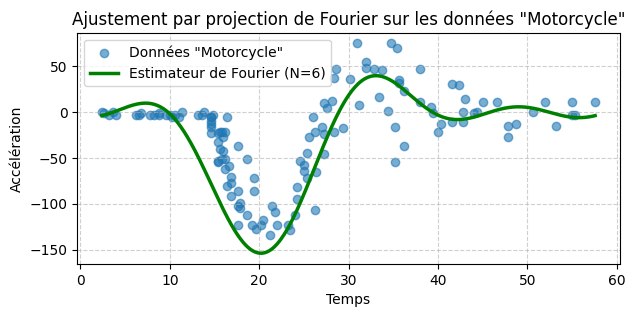

In [ ]:
# Grille de N à tester
N_candidates_real = np.arange(2, 51)
cv_scores_real = []

for N_val in N_candidates_real:
    score = cross_validation_score(X_norm, Y_real, N_val)
    cv_scores_real.append(score)

# Trouver le N optimal
N_optimal_real = N_candidates_real[np.argmin(cv_scores_real)]
print(f"La valeur optimale de N pour les données 'motorcycle' est : {N_optimal_real}")

# Calculer l'estimateur final
coeffs_optimal_real = calculate_coeffs(X_norm, Y_real, N_optimal_real)
x_grid_norm = np.linspace(0, 1, 500) # Grille normalisée
y_est_optimal_real = fourier_estimator(x_grid_norm, coeffs_optimal_real)

# On dé-normalise la grille pour l'affichage
x_grid_real = x_grid_norm * (X_max - X_min) + X_min

# Graphique final
plt.figure(figsize=(7,3))
plt.scatter(X_real, Y_real, label='Données "Motorcycle"', alpha=0.6)
plt.plot(x_grid_real, y_est_optimal_real,
         label=f'Estimateur de Fourier (N={N_optimal_real})',
         color='green', linewidth=2.5)
plt.title('Ajustement par projection de Fourier sur les données "Motorcycle"')
plt.xlabel('Temps')
plt.ylabel('Accélération')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

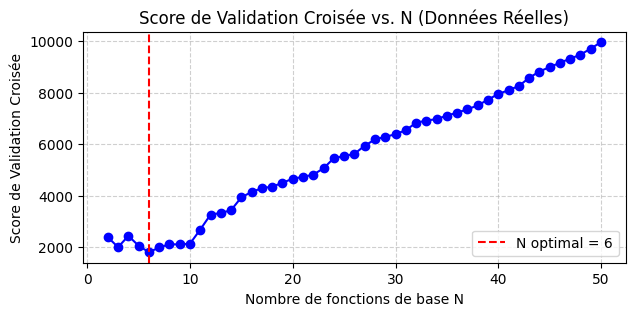

In [ ]:
# @title
# Code pour tracer les scores CV de l'EXERCICE 2
plt.figure(figsize=(7,3))
plt.plot(N_candidates_real, cv_scores_real, marker='o', linestyle='-', color='blue')
plt.axvline(x=N_optimal_real, color='red', linestyle='--',
            label=f'N optimal = {N_optimal_real}')
plt.title('Score de Validation Croisée vs. N (Données Réelles)')
plt.xlabel('Nombre de fonctions de base N')
plt.ylabel('Score de Validation Croisée')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()